In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('wine_data.csv', header = None , usecols=[0,1,2])
df.columns=['class labels', 'Alcohol', 'Malic acid']

<Axes: xlabel='Alcohol', ylabel='Density'>

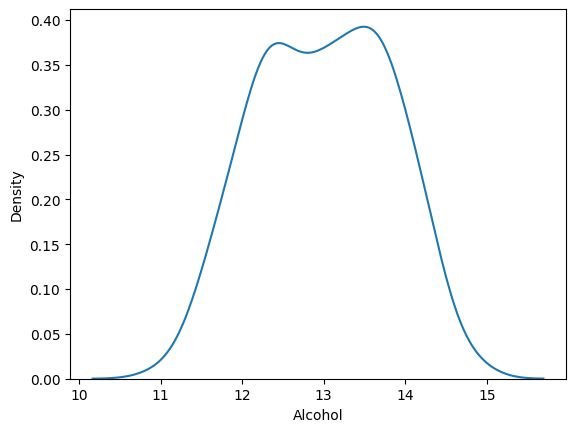

In [15]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

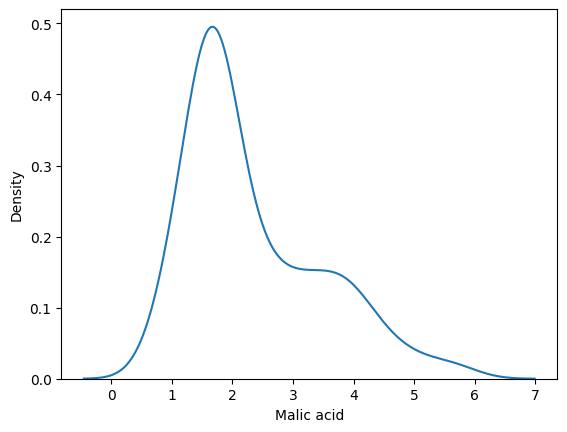

In [16]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

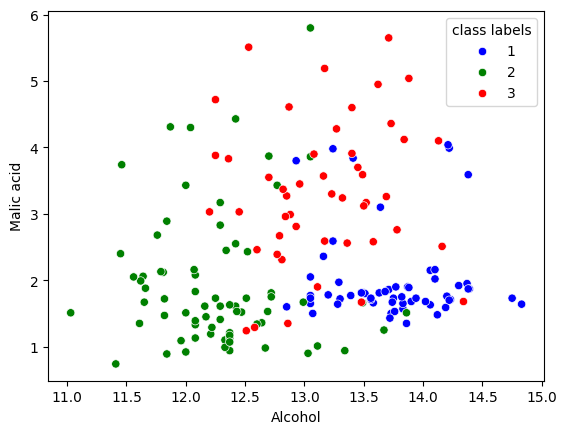

In [17]:
color_dict={1:'Blue', 2:'green',3:'red'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['class labels'],palette=color_dict)

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df[['Alcohol','Malic acid']], df['class labels'], test_size=0.3, random_state=0)

x_train.shape , x_test.shape 

((124, 2), (54, 2))

In [19]:
np.round(x_train.describe() , 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


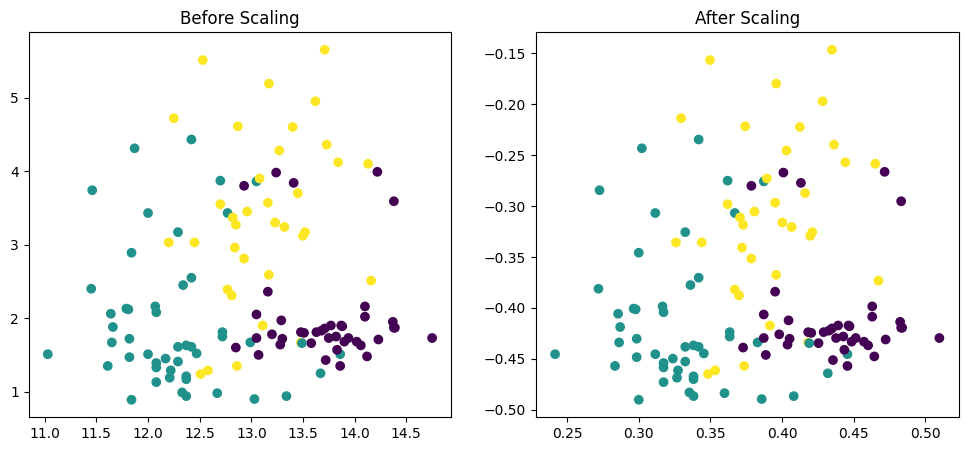

In [42]:
def mean_normalization(x_train, x_test):
    x_train_norm = (x_train - np.mean(x_train)) / (np.max(x_train) - np.min(x_train))
    x_test_norm = (x_test - np.mean(x_test)) / (np.max(x_test) - np.min(x_test))
    return x_train_norm, x_test_norm

x_train_scaled, x_test_scaled = mean_normalization(x_train, x_test)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Alcohol'], x_train['Malic acid'], c=y_train)
ax1.set_title("Before Scaling")

ax2.scatter(x_train_scaled['Alcohol'], x_train_scaled['Malic acid'], c=y_train)
ax2.set_title("After Scaling")

plt.show()

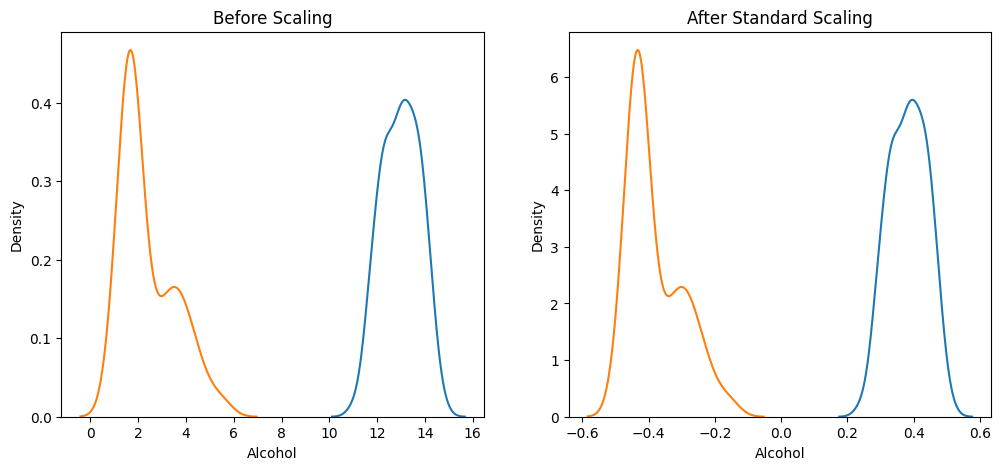

In [46]:

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Alcohol'], ax=ax1)
sns.kdeplot(x_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(x_train_scaled['Malic acid'], ax=ax2)
plt.show()